# Edge IIoT - Anomaly Detection - K-Means

## 0. Imports

In [16]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report,
    confusion_matrix
)
from scipy.spatial.distance import cdist

from src.preprocessing import Utils, Resamplers, Filters
from src.config import DATASETS, SEED

np.random.seed(SEED)
print(f'NumPy seed set to {SEED}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
NumPy seed set to 42


## 1. Data Loading

In [17]:
dataset_name = 'edge_iiot'
config       = DATASETS[dataset_name]

filename = 'DL-EdgeIIoT-dataset_clean'
csv_path = config['processed_path'] / f'{filename}.pkl'

print('Loading dataset...')
df = pd.read_pickle(csv_path)
print(f'Dataset shape : {df.shape}')

Loading dataset...
Dataset shape : (2158750, 62)


## 2. Pre-processing 

In [18]:
cols_to_drop = [
    'frame.time.delta', 'frame.time.order',
    *[c for c in df.columns if c.startswith('ip.src_category') or c.startswith('ip.dst_category')]
]
df = df.drop(columns=cols_to_drop, errors='ignore')

In [19]:
from sklearn.pipeline import Pipeline

preprocessing_pipeline = Pipeline([
    ("filter_invalid_time", Filters.ValidTimeFilter()),
    ("drop_categorical",    Filters.CategoricalDropper()),
    ("train_test_split",    Utils.AnomalyTrainTestSplitter()),
    ('xysplit',             Utils.SplitExtractor())
])

X_train, X_test, y_train, y_test, _, y_mc_test, X_val, y_val, _  = preprocessing_pipeline.fit_transform(df)


  [ValidTimeFilter] Dropped 122,596 rows  →  (2036154, 52)
  [CategoricalDropper] Dropped 7 categorical columns: ['http.file_data', 'http.referer', 'http.request.path', 'http.request.uri.query', 'http.request.version', 'mqtt.msg', 'proto']  →  (2036154, 45)
  [AnomalyTrainTestSplitter]
    Train: 1,130,949 (Normal only)
    Val:   301,734 (161,564 Normal + 140,170 attacks)
    Test:  603,471 (323,129 Normal + 280,342 attacks)
  [SplitExtractor] X_train: (1130949, 43)  |  X_test: (603471, 43)  |  y_bin_train: (1130949,) | y_15c_train: (1130949,) | y_bin_test: (603471,) | y_15c_test: (603471,)
  [SplitExtractor] X_val: (301734, 43) | y_bin_val: (301734,) | y_15c_val: (301734,)


In [20]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'Train scaled : {X_train_scaled.shape}')
print(f'Val   scaled : {X_val_scaled.shape}'  )
print(f'Test  scaled : {X_test_scaled.shape}' )

Train scaled : (1130949, 43)
Val   scaled : (301734, 43)
Test  scaled : (603471, 43)


In [21]:
actual_rate = (y_train == 1).mean()
print(f"Attack rate in training pool:{actual_rate*100:.2f}%")

Attack rate in training pool:0.00%


## 3. K-Means (KM) Definition

### Threshold Function

In [22]:
def threshold_from_train_quantile(train_scores, q=0.95):
    return np.quantile(train_scores, q)

### Distance Functions


In [ ]:
from typing import Callable


def _min_dist(x: np.ndarray, centroids: np.ndarray, metric: str) -> np.ndarray:
    """Distance from each sample to its nearest centroid under `metric`."""
    return cdist(x, centroids, metric=metric).min(axis=1)


def euclidean_score(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """L2 distance to the nearest centroid. Matches the K-Means objective."""
    return _min_dist(x, centroids, "euclidean")


def manhattan_score(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """L1 distance to the nearest centroid. More robust to outlier features."""
    return _min_dist(x, centroids, "cityblock")


def sqeuclidean_score(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """Squared L2 distance. Inflates large residuals, like MSE."""
    return _min_dist(x, centroids, "sqeuclidean")


def cosine_score(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """1 - cosine similarity to the nearest centroid. Captures directional
    mismatch rather than magnitude; useful when feature scales vary.
    """
    eps = 1e-8
    x = np.asarray(x, dtype=float)
    centroids = np.asarray(centroids, dtype=float)
    x_norm = np.linalg.norm(x, axis=1, keepdims=True)
    c_norm = np.linalg.norm(centroids, axis=1, keepdims=True)
    sim = (x @ centroids.T) / (x_norm * c_norm.T + eps)
    return (1.0 - sim).min(axis=1)


def chebyshev_score(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """Chebyshev (L-inf) distance: the single largest per-feature deviation
    from the nearest centroid."""
    return _min_dist(x, centroids, "chebyshev")

In [24]:
DISTANCE_FUNCTIONS: dict[str, Callable[[np.ndarray, np.ndarray], np.ndarray]] = {
    "euclidean": euclidean_score,
    "manhattan": manhattan_score,
    "sqeuclidean": sqeuclidean_score,
    "cosine": cosine_score,
    "chebyshev": chebyshev_score,
}

### Modular Detector

In [ ]:
class KMeansAnomalyDetector:
    """K-Means anomaly detector with a configurable number of clusters."""

    def __init__(
        self,
        n_clusters: int = 8,
        init: str = "k-means++",
        n_init: int = 10,
        max_iter: int = 300,
        random_state: int = SEED,
    ):
        self.n_clusters = n_clusters
        self.init = init
        self.n_init = n_init
        self.max_iter = max_iter
        self.random_state = random_state
        self._km = KMeans(
            n_clusters=n_clusters,
            init=init,
            n_init=n_init,
            max_iter=max_iter,
            random_state=random_state,
        )

    @property
    def centroids_(self) -> np.ndarray:
        return self._km.cluster_centers_

    @property
    def inertia_(self) -> float:
        return self._km.inertia_

    @property
    def n_iter_(self) -> int:
        return self._km.n_iter_

    def fit(self, X: np.ndarray) -> "KMeansAnomalyDetector":
        self._km.fit(X)
        return self

    def anomaly_score(
        self,
        x: np.ndarray,
        distance_fn: str | Callable[[np.ndarray, np.ndarray], np.ndarray] = "euclidean",
    ) -> np.ndarray:
        """Per-sample distance to the nearest centroid, used as anomaly score."""
        if isinstance(distance_fn, str):
            try:
                distance_fn = DISTANCE_FUNCTIONS[distance_fn]
            except KeyError:
                raise ValueError(
                    f"Unknown distance_fn '{distance_fn}'. "
                    f"Choose from {list(DISTANCE_FUNCTIONS)} or pass a callable."
                )
        return distance_fn(np.asarray(x), self.centroids_)

### Fitting Function

In [ ]:
def fit_kmeans(
    model,
    X_train,
    verbose: bool = True,
):
    """Fit a KMeansAnomalyDetector on the normal-only training data."""
    n_train = len(X_train)
    if verbose:
        print(
            f"Fitting K-Means (k={model.n_clusters}, init='{model.init}', "
            f"n_init={model.n_init}) on {n_train:,} normal samples "
            f"(input_dim={X_train.shape[1]})..."
        )
    t0 = time.time()
    model.fit(X_train)
    fit_time = time.time() - t0

    history = {
        "inertia": float(model.inertia_),
        "n_iter": int(model.n_iter_),
        "fit_time": fit_time,
    }

    if verbose:
        print(
            f"  Fitted in {fit_time:.1f}s | inertia={history['inertia']:.2f} | "
            f"converged in {history['n_iter']} iterations"
        )

    return history

## 4. KM Experiments

### Training Data

In [ ]:
X_km_train = X_train_scaled

X_val_normal_scaled = X_val_scaled[y_val == 0]   # normal-only val for thresholding
X_km_val   = X_val_normal_scaled
X_km_test  = X_test_scaled

print(f'KM train  : {X_km_train.shape} (normal-only pool)')
print(f'KM val    : {X_km_val.shape} (normal-only, thresholding)')
print(f'KM test   : {X_km_test.shape}')

KM train  : (1130949, 43) (normal-only pool)
KM val    : (161564, 43) (normal-only, thresholding)
KM test   : (603471, 43)


### Exp function

In [ ]:
def run_km_experiment(
    name,
    n_clusters,
    *,
    init="k-means++",
    n_init=10,
    max_iter=300,
    distance_fns=("euclidean",),
    threshold_fpr=0.01,
    seed=SEED,
    verbose=False,
):
    """Build, fit and evaluate one K-Means configuration."""
    np.random.seed(seed)

    model = KMeansAnomalyDetector(
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        random_state=seed,
    )

    n_params = n_clusters * X_km_train.shape[1]   # size of the centroid matrix

    t0 = time.time()
    history = fit_kmeans(model, X_km_train, verbose=verbose)
    fit_time = time.time() - t0

    per_loss = {}
    for df_name in distance_fns:
        val_scores  = model.anomaly_score(X_km_val,  distance_fn=df_name)
        test_scores = model.anomaly_score(X_km_test, distance_fn=df_name)

        thr = threshold_from_train_quantile(val_scores, q=1.0 - threshold_fpr)
        val_fpr = float((val_scores >= thr).mean())   # realised FPR on normal val

        auroc = roc_auc_score(y_test, test_scores)
        auprc = average_precision_score(y_test, test_scores)

        y_pred = (test_scores >= thr).astype(int)
        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        per_loss[df_name] = dict(
            AUROC=auroc,
            AUPRC=auprc,
            F1=rep["1"]["f1-score"],
            Precision=rep["1"]["precision"],
            Recall=rep["1"]["recall"],
            threshold=float(thr),
            val_fpr=val_fpr,
            y_pred=y_pred,
        )

    return dict(
        name=name,
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        inertia=history["inertia"],
        n_iter=history["n_iter"],
        n_params=n_params,
        fit_time=fit_time,
        history=history,
        per_loss=per_loss,
        model=model,
    )

### Configs (MODIFYME)

In [ ]:
KM_CONFIGS = [
    # Number of clusters (k) sweep
    dict(name="k4",   n_clusters=4),
    dict(name="k8",   n_clusters=8),
    dict(name="k16",  n_clusters=16),
    dict(name="k24",  n_clusters=24),
    dict(name="k32",  n_clusters=32),
    dict(name="k48",  n_clusters=48),
    dict(name="k64",  n_clusters=64),
    dict(name="k96",  n_clusters=96),
]

EVAL_LOSSES = ["euclidean", "manhattan", "sqeuclidean", "cosine", "chebyshev"]

N_INIT        = 10      # K-Means re-initialisations; best inertia kept
THRESHOLD_FPR = 0.05    # target false-positive rate on normal traffic

### Execution

In [30]:
arch_runs = {}
for cfg in KM_CONFIGS:
    print(f"\n--- {cfg['name']} | k={cfg['n_clusters']} ---")
    run = run_km_experiment(
        cfg["name"], cfg["n_clusters"],
        init="k-means++",
        n_init=N_INIT,
        distance_fns=EVAL_LOSSES,
        threshold_fpr=THRESHOLD_FPR,
        verbose=True,
    )
    arch_runs[cfg["name"]] = run
    m = run["per_loss"]["euclidean"]
    print(f"  k={run['n_clusters']}  inertia={run['inertia']:.1f}  "
          f"params={run['n_params']:,}  "
          f"AUROC(euclidean)={m['AUROC']:.4f}  F1(euclidean)={m['F1']:.4f}  "
          f"Recall(euclidean)={m['Recall']:.4f}  val_FPR={m['val_fpr']:.3f}")


--- k4 | k=4 ---
Fitting K-Means (k=4, init='k-means++', n_init=10) on 1,130,949 normal samples (input_dim=43)...
  Fitted in 3.4s | inertia=501237.66 | converged in 3 iterations
  k=4  inertia=501237.7  params=172  AUROC(euclidean)=0.6851  F1(euclidean)=0.4401  Recall(euclidean)=0.2998  val_FPR=0.054

--- k8 | k=8 ---
Fitting K-Means (k=8, init='k-means++', n_init=10) on 1,130,949 normal samples (input_dim=43)...
  Fitted in 6.3s | inertia=143916.11 | converged in 3 iterations
  k=8  inertia=143916.1  params=344  AUROC(euclidean)=0.7804  F1(euclidean)=0.5428  Recall(euclidean)=0.3975  val_FPR=0.060

--- k16 | k=16 ---
Fitting K-Means (k=16, init='k-means++', n_init=10) on 1,130,949 normal samples (input_dim=43)...
  Fitted in 12.0s | inertia=1451.79 | converged in 15 iterations
  k=16  inertia=1451.8  params=688  AUROC(euclidean)=0.7368  F1(euclidean)=0.6791  Recall(euclidean)=0.5430  val_FPR=0.050

--- k24 | k=24 ---
Fitting K-Means (k=24, init='k-means++', n_init=10) on 1,130,949 n

## 5. Exp Comparison

In [31]:
METRIC_KEYS = ["AUROC", "AUPRC", "F1", "Precision", "Recall", "val_fpr"]


def _metrics_only(d):
    return {k: d[k] for k in METRIC_KEYS}


# ---------------------------------------------------------------
arch_df = (
    pd.DataFrame([
        dict(Model=r["name"], k=r["n_clusters"], inertia=r["inertia"],
             n_params=r["n_params"], fit_time=r["fit_time"],
             n_iter=r["n_iter"],
             **_metrics_only(r["per_loss"]["euclidean"]))
        for r in arch_runs.values()
    ])
    .set_index("Model")
)

# ---------------------------------------------------------------
loss_df = pd.DataFrame([
    dict(Model=r["name"], loss=df_name, **_metrics_only(metrics))
    for r in arch_runs.values()
    for df_name, metrics in r["per_loss"].items()
])

pivot_auroc = loss_df.pivot(index="Model", columns="loss", values="AUROC")
pivot_f1    = loss_df.pivot(index="Model", columns="loss", values="F1")

print("=== Cluster sweep (Euclidean scoring, unsupervised threshold) ===")
print(arch_df.sort_values("AUROC", ascending=False)
            .to_string(float_format="{:.4f}".format))
print("\n=== AUROC by k x distance function (threshold-free) ===")
print(pivot_auroc.to_string(float_format="{:.4f}".format))

=== Cluster sweep (Euclidean scoring, unsupervised threshold) ===
        k     inertia  n_params  fit_time  n_iter  AUROC  AUPRC     F1  Precision  Recall  val_fpr
Model                                                                                             
k8      8 143916.1077       344    6.2743       3 0.7804 0.8010 0.5428     0.8557  0.3975   0.0601
k96    96     18.0316      4128   44.8580      26 0.7617 0.8091 0.6912     0.9061  0.5587   0.0500
k64    64     35.8538      2752   44.8598      27 0.7538 0.8034 0.6833     0.9061  0.5485   0.0500
k16    16   1451.7913       688   11.9861      15 0.7368 0.7956 0.6791     0.9063  0.5430   0.0500
k24    24    306.1813      1032   18.0909      15 0.7367 0.7926 0.6687     0.9033  0.5308   0.0500
k32    32    148.4731      1376   23.0979      15 0.7339 0.7950 0.6905     0.9068  0.5575   0.0500
k48    48     65.0124      2064   31.8215      11 0.7315 0.7928 0.6817     0.9046  0.5469   0.0500
k4      4 501237.6641       172    3.3856  

### Clusters vs Metrics

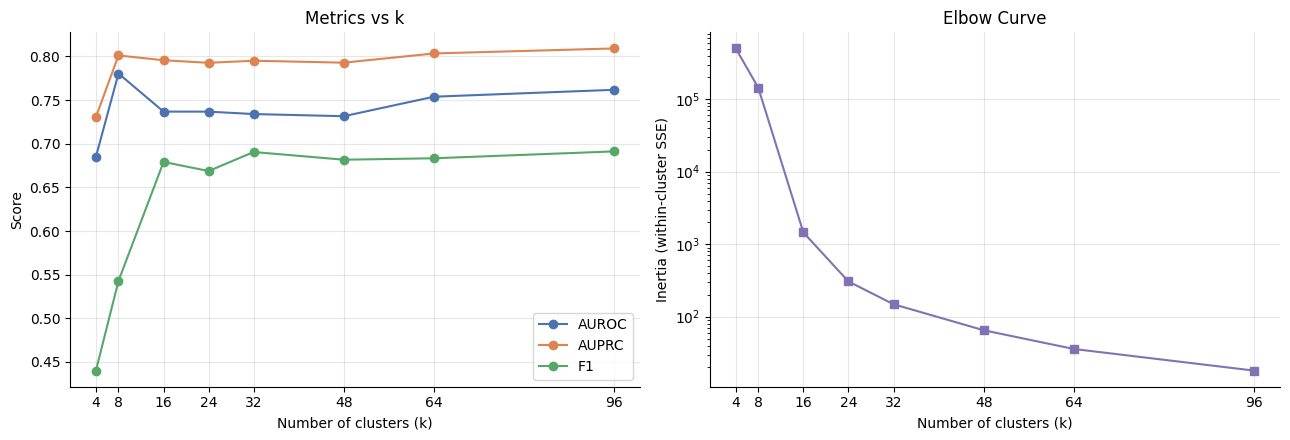

In [ ]:
metrics_plot = ["AUROC", "AUPRC", "F1"]
palette      = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (Left) detection metrics vs number of clusters
g_k = arch_df.sort_values("k")
for m, c in zip(metrics_plot, palette):
    axes[0].plot(g_k["k"], g_k[m], marker="o", color=c, label=m)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Score")
axes[0].set_title("Metrics vs k")
axes[0].set_xticks(sorted(arch_df["k"].unique()))
axes[0].grid(alpha=0.3)
axes[0].legend()

# (Right) inertia vs n of clusters
axes[1].plot(g_k["k"], g_k["inertia"], marker="s", color="#8172B3")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Inertia (within-cluster SSE)")
axes[1].set_title("Elbow Curve")
axes[1].set_xticks(sorted(arch_df["k"].unique()))
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Comparison Distance Functions

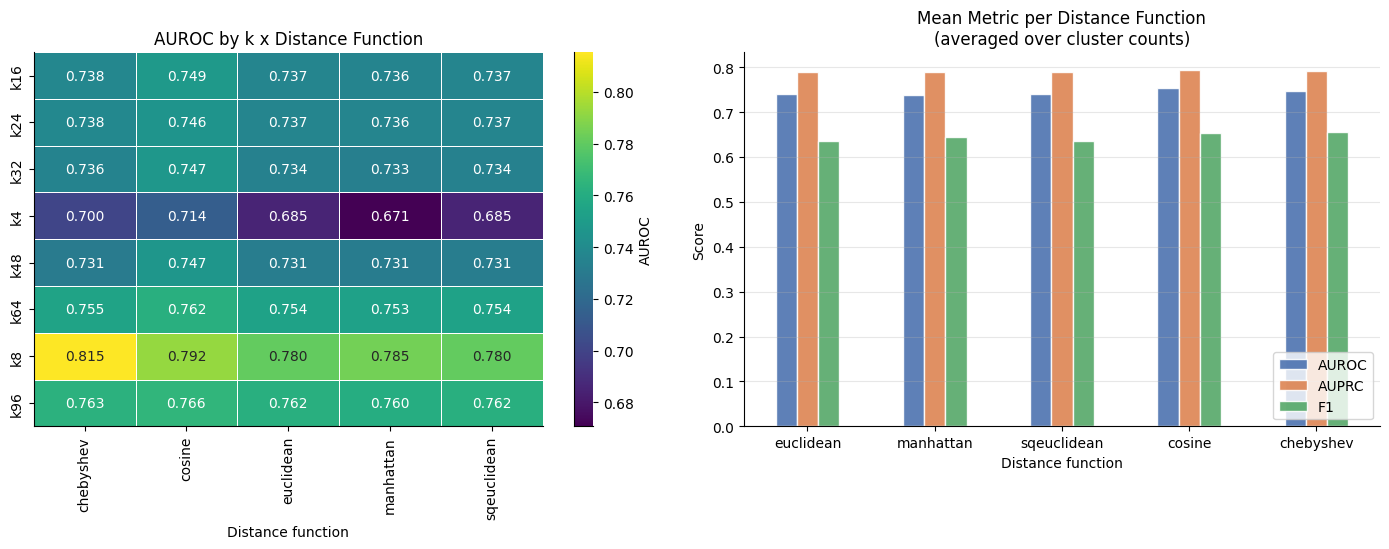

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(4.0, len(arch_runs) * 0.7)))

# ---------------------------------------------------------------
# (Left) AUROC heatmap
sns.heatmap(
    pivot_auroc, annot=True, fmt=".3f", cmap="viridis",
    linewidths=0.5, ax=axes[0], cbar_kws={"label": "AUROC"},
)
axes[0].set_title("AUROC by k x Distance Function")
axes[0].set_xlabel("Distance function")
axes[0].set_ylabel("")

# ---------------------------------------------------------------
# (Right) Mean metric by distance function (averaged over cluster counts)
mean_by_loss = loss_df.groupby("loss")[["AUROC", "AUPRC", "F1"]].mean()
mean_by_loss = mean_by_loss.loc[EVAL_LOSSES]          # keep declared order
mean_by_loss.plot(
    kind="bar", ax=axes[1],
    color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.9, edgecolor="white",
)
axes[1].set_title("Mean Metric per Distance Function\n(averaged over cluster counts)")
axes[1].set_xlabel("Distance function")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(loc="lower right")

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Confusion Matrices

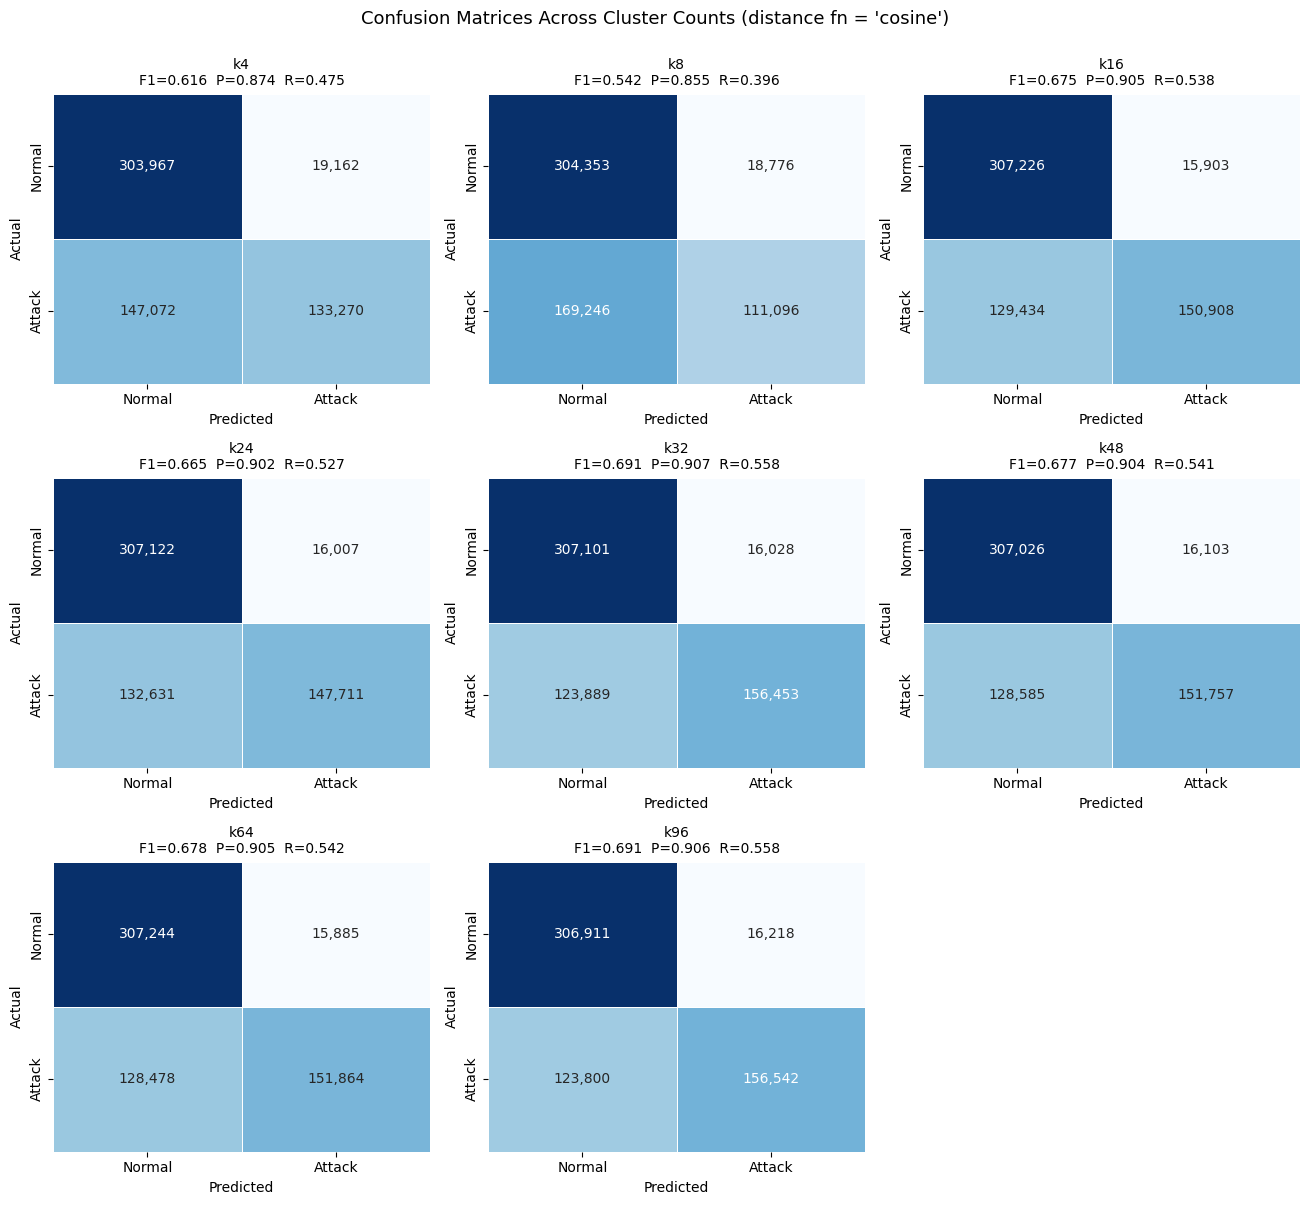

In [35]:
CM_DISTANCE_FN = "cosine"

cm_labels = ["Normal", "Attack"]
n_runs = len(arch_runs)
ncols  = 3
nrows  = int(np.ceil(n_runs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.0 * nrows), squeeze=False)
for ax, (name, r) in zip(axes.flat, arch_runs.items()):
    info = r["per_loss"][CM_DISTANCE_FN]
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
        xticklabels=cm_labels, yticklabels=cm_labels, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(
        f"{name}\nF1={info['F1']:.3f}  "
        f"P={info['Precision']:.3f}  R={info['Recall']:.3f}",
        fontsize=10,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes.flat[n_runs:]:
    ax.set_visible(False)

fig.suptitle(
    f"Confusion Matrices Across Cluster Counts (distance fn = '{CM_DISTANCE_FN}')",
    fontsize=13, y=1.0,
)
plt.tight_layout()
plt.show()

## 6. Best KM

In [36]:
best_idx = loss_df["AUROC"].idxmax()
best = loss_df.loc[best_idx]
best_cfg = arch_runs[best["Model"]]
best_info = best_cfg["per_loss"][best["loss"]]

print("Best configuration by AUROC")
print(f"  Clusters     : {best['Model']}  (k={best_cfg['n_clusters']})")
print(f"  Distance fn  : {best['loss']}")
print(f"  AUROC={best['AUROC']:.4f}  AUPRC={best['AUPRC']:.4f}")
print(f"  Operating point @ {THRESHOLD_FPR:.0%} target FPR "
      f"(normal-val FPR={best_info['val_fpr']:.3f}, threshold={best_info['threshold']:.4f}):")
print(f"    F1={best['F1']:.4f}  Precision={best['Precision']:.4f}  Recall={best['Recall']:.4f}")
print(f"  Inertia      : {best_cfg['inertia']:.1f}   "
      f"Params: {best_cfg['n_params']:,}   "
      f"Fit time: {best_cfg['fit_time']:.1f}s")

Best configuration by AUROC
  Clusters     : k8  (k=8)
  Distance fn  : chebyshev
  AUROC=0.8154  AUPRC=0.7995
  Operating point @ 5% target FPR (normal-val FPR=0.060, threshold=0.8881):
    F1=0.5983  Precision=0.8718  Recall=0.4554
  Inertia      : 143916.1   Params: 344   Fit time: 6.3s


### Confussion Matrixes per distance function

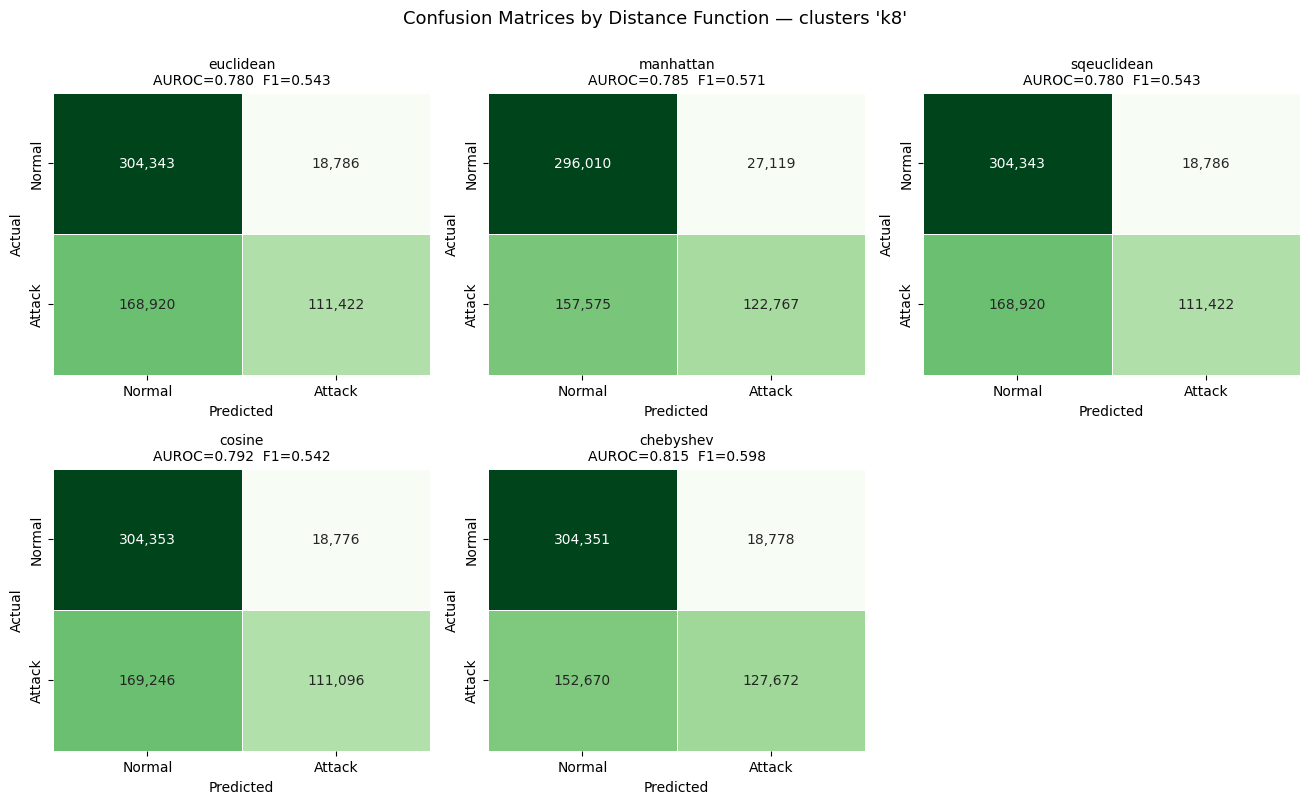

In [37]:
best_arch_name = arch_df["AUROC"].idxmax()
best_run = arch_runs[best_arch_name]

n_losses = len(EVAL_LOSSES)
ncols    = 3
nrows    = int(np.ceil(n_losses / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.0 * nrows), squeeze=False)
for ax, df_name in zip(axes.flat, EVAL_LOSSES):
    info = best_run["per_loss"][df_name]
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Greens", cbar=False,
        xticklabels=cm_labels, yticklabels=cm_labels, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(
        f"{df_name}\nAUROC={info['AUROC']:.3f}  F1={info['F1']:.3f}",
        fontsize=10,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes.flat[n_losses:]:
    ax.set_visible(False)

fig.suptitle(
    f"Confusion Matrices by Distance Function — clusters '{best_arch_name}'",
    fontsize=13, y=1.0,
)
plt.tight_layout()
plt.show()

### Per-class detection rate

Per-class detection rate — best model: k8 / chebyshev (threshold @ 5% target FPR)

                Class   Kind  Support  Detected  Accuracy
            DDoS_ICMP Attack    51428     51428    1.0000
       Fingerprinting Attack      692       600    0.8671
Vulnerability_scanner Attack    33371     28826    0.8638
        Port_Scanning Attack    15015      8331    0.5548
            Uploading Attack    25155      8973    0.3567
                  XSS Attack    10554      3701    0.3507
        SQL_injection Attack    33967     11620    0.3421
             Password Attack    33585     10352    0.3082
           Ransomware Attack     7269      1161    0.1597
             Backdoor Attack    16630      1075    0.0646
            DDoS_HTTP Attack    33252      1603    0.0482
             DDoS_TCP Attack    19424         2    0.0001
               Normal Normal   323129     18778    0.9419

  Macro (per-class mean) accuracy : 0.4506
  Attack-only mean detection rate : 0.4097


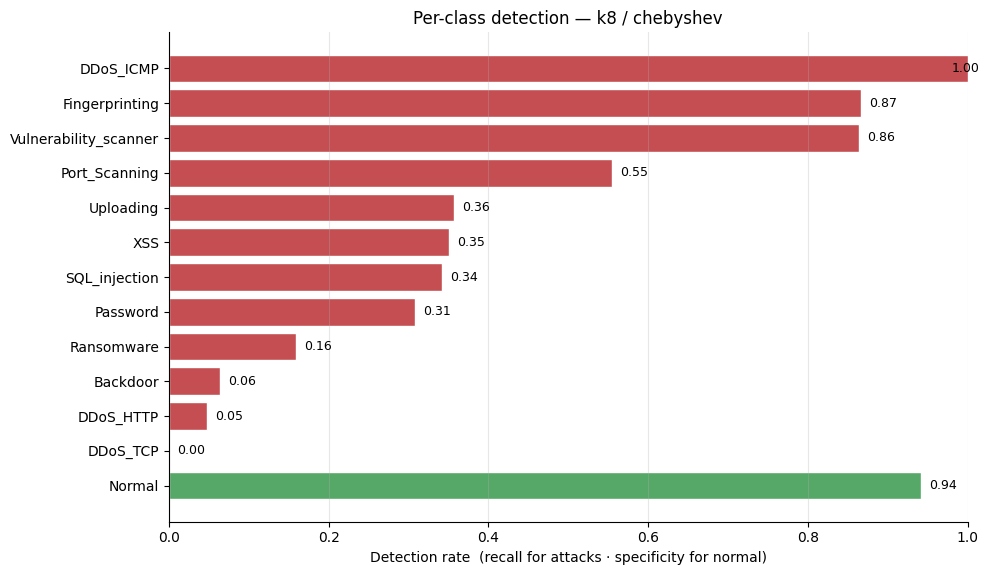

In [38]:
y_pred_best = best_info["y_pred"]
mc = np.asarray(y_mc_test)

rows = []
for cls in pd.unique(mc):
    mask = mc == cls
    n = int(mask.sum())
    is_attack = (y_test[mask] == 1).all()
    correct = y_pred_best[mask] == 1 if is_attack else y_pred_best[mask] == 0
    rows.append(dict(
        Class=str(cls),
        Kind="Attack" if is_attack else "Normal",
        Support=n,
        Detected=int((y_pred_best[mask] == 1).sum()),
        Accuracy=float(correct.mean()),
    ))

per_class_df = (
    pd.DataFrame(rows)
    .sort_values(["Kind", "Accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

# ---------------------------------------------------------------
#  Print
print(f"Per-class detection rate — best model: "
      f"{best['Model']} / {best['loss']} "
      f"(threshold @ {THRESHOLD_FPR:.0%} target FPR)\n")
print(per_class_df.to_string(
    index=False, float_format="{:.4f}".format))

print(f"\n  Macro (per-class mean) accuracy : {per_class_df['Accuracy'].mean():.4f}")
print(f"  Attack-only mean detection rate : "
      f"{per_class_df.loc[per_class_df['Kind']=='Attack','Accuracy'].mean():.4f}")

# ---------------------------------------------------------------
#  Figure
fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * len(per_class_df))))
colors = ["#55A868" if k == "Normal" else "#C44E52" for k in per_class_df["Kind"]]
ax.barh(per_class_df["Class"], per_class_df["Accuracy"], color=colors, edgecolor="white")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_xlabel("Detection rate  (recall for attacks · specificity for normal)")
ax.set_title(f"Per-class detection — {best['Model']} / {best['loss']}")
for y, v in enumerate(per_class_df["Accuracy"]):
    ax.text(min(v + 0.01, 0.98), y, f"{v:.2f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()